# FRAUD DETECTION CASE STUDIES

# Part 1: Business Understanding

## 1.1 Background Information
This dataset contains credit card transactions made by European cardholders in the year 2023. It comprises over 550,000 records, and the data has been anonymized to protect the cardholders' identities.

## 1.2 Business Objectives
The primary objective of this dataset is to facilitate the development of fraud detection algorithms and models to identify potentially fraudulent transactions.

## 1.3 Data Mining Goals
- Explore data patterns and distributions
- Identify correlations between features
- Handle missing values appropriately
- Apply feature selection techniques
- Build classification model for fraud detection


# Part 2: Data Understanding

## 2.1 Import Libraries and Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
# Plotting configurations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the Kaggle Credit Card Fraud Dataset
# Note: Ensure 'creditcard.csv' is in your directory or Google Drive
try:
    df = pd.read_csv('/content/drive/MyDrive/data/creditcard.csv')
    print(f"✅ Dataset loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Error: 'creditcard.csv' not found. Please upload it to your workspace.")
    # At the end of your plotting code blocks, make sure this is present:
plt.show()

✅ Dataset loaded successfully! Shape: (284807, 31)


In [3]:
import sys
!{sys.executable} -m pip install optuna
print('Optuna installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
Optuna installed successfully!


## 2.2 Describe Data

Now that the dataset is loaded, we'll perform an initial inspection to understand its structure, data types, and general statistical characteristics. This step is crucial for identifying potential issues and planning subsequent data cleaning and preprocessing.

### 2.2.1 General Characteristics



In [4]:
# Display the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display basic information about the DataFrame, including data types and non-null counts
print("\n--- DataFrame Info ---")
df.info()

Number of rows: 284807
Number of columns: 31

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 no

### 2.2.2 Basic Statistics of the Dataset


In [5]:
# Display descriptive statistics for numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 2.2.3 Feature Renaming

To standardize the feature names and improve readability, we will rename the principal component features (V1-V28) to 'feature_1' through 'feature_28'. This makes it easier to refer to them programmatically.

In [6]:

# Create a dictionary for renaming V-columns to feature_X
rename_dict = {f'V{i}': f'feature_{i}' for i in range(1, 29)}

# Rename the columns in the DataFrame
df = df.rename(columns=rename_dict)

print("Columns renamed successfully!")

# Display the first few rows with new column names
display(df.head())

Columns renamed successfully!


,Time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2.7 Data Exploration

### 2.7.1 Constant Features
Features that have only one unique value (i.e., constant features) provide no information for machine learning models and can be safely removed. We will identify and list any such features.

In [7]:
# Identify constant features
constant_features = [col for col in df.columns if df[col].nunique() == 1]

if constant_features:
    print(f"Found {len(constant_features)} constant features: {constant_features}")
    # Optionally, drop these features
    # df = df.drop(columns=constant_features)
    # print(f"Removed constant features. New DataFrame shape: {df.shape}")
else:
    print("No constant features found in the DataFrame.")

No constant features found in the DataFrame.


### 2.7.2 Low Variance Features

Features with very low variance might also contribute little to a model's predictive power. While not always removed, it's good to be aware of them. We'll look for features where the standard deviation is very close to zero.

In [8]:
# Identify low variance features (e.g., standard deviation very close to zero)
low_variance_threshold = 0.01
low_variance_features = [col for col in df.columns if df[col].std() < low_variance_threshold and col != 'Class']

if low_variance_features:
    print(f"Found {len(low_variance_features)} low variance features: {low_variance_features}")
    for col in low_variance_features:
        print(f"  - {col}: Std Dev = {df[col].std():.6f}")
else:
    print("No features with variance below the specified threshold found.")

No features with variance below the specified threshold found.


### 2.7.3 Target Variable Distribution

The 'Class' column represents whether a transaction is fraudulent (1) or legitimate (0). Analyzing its distribution is essential to understand the class imbalance, a common characteristic in fraud detection datasets. This imbalance often requires special handling during model training.

Class Distribution:


,count
Class,
0,284315
1,492



Percentage of each class:


,proportion
Class,
0,99.827251
1,0.172749


/tmp/ipykernel_3029/1868476714.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette=['skyblue', 'salmon'])


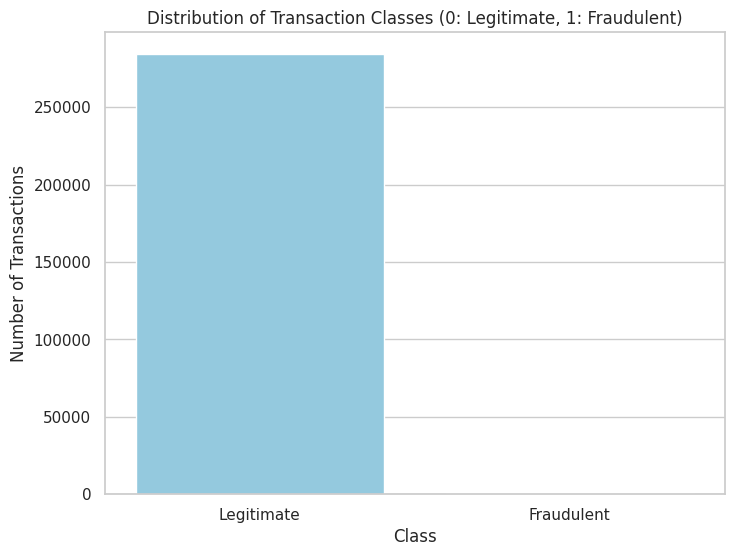

In [9]:
# Check the distribution of the 'Class' variable
class_distribution = df['Class'].value_counts()

print("Class Distribution:")
display(class_distribution)

print("\nPercentage of each class:")
display(df['Class'].value_counts(normalize=True) * 100)

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette=['skyblue', 'salmon'])
plt.title('Distribution of Transaction Classes (0: Legitimate, 1: Fraudulent)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
plt.show()

## 2.8 Check Data Quality

### 2.8.1 Duplicate Rows Check

Duplicate rows in a dataset can lead to biased models and inaccurate insights. We will identify and remove any duplicate transaction records to ensure data integrity.

In [10]:
duplicate_rows_count = df.duplicated().sum()

print(f"Number of duplicate rows found: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    # Remove duplicate rows
    df_cleaned = df.drop_duplicates()
    print(f"{duplicate_rows_count} duplicate rows removed.")
    print(f"New DataFrame shape after removing duplicates: {df_cleaned.shape}")
    df = df_cleaned # Update df to the cleaned DataFrame
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 1081
1081 duplicate rows removed.
New DataFrame shape after removing duplicates: (283726, 31)


### 2.8.2 Missing Values Check

Missing values can cause errors or biases in analysis and modeling. We will check for any missing values across all columns and visualize their distribution if any are found.

In [11]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Missing values found per column:")
    print(missing_values)
else:
    print("No missing values found in the DataFrame.")

No missing values found in the DataFrame.


Remove missing values from the data set since they account for such a small percentage of the data

### 2.8.3 Data Distribution Analysis

Understanding the distribution of individual features is essential for identifying potential issues like skewness, outliers, and the overall shape of the data. This analysis will guide us in selecting appropriate preprocessing techniques (e.g., scaling, transformations) if needed.

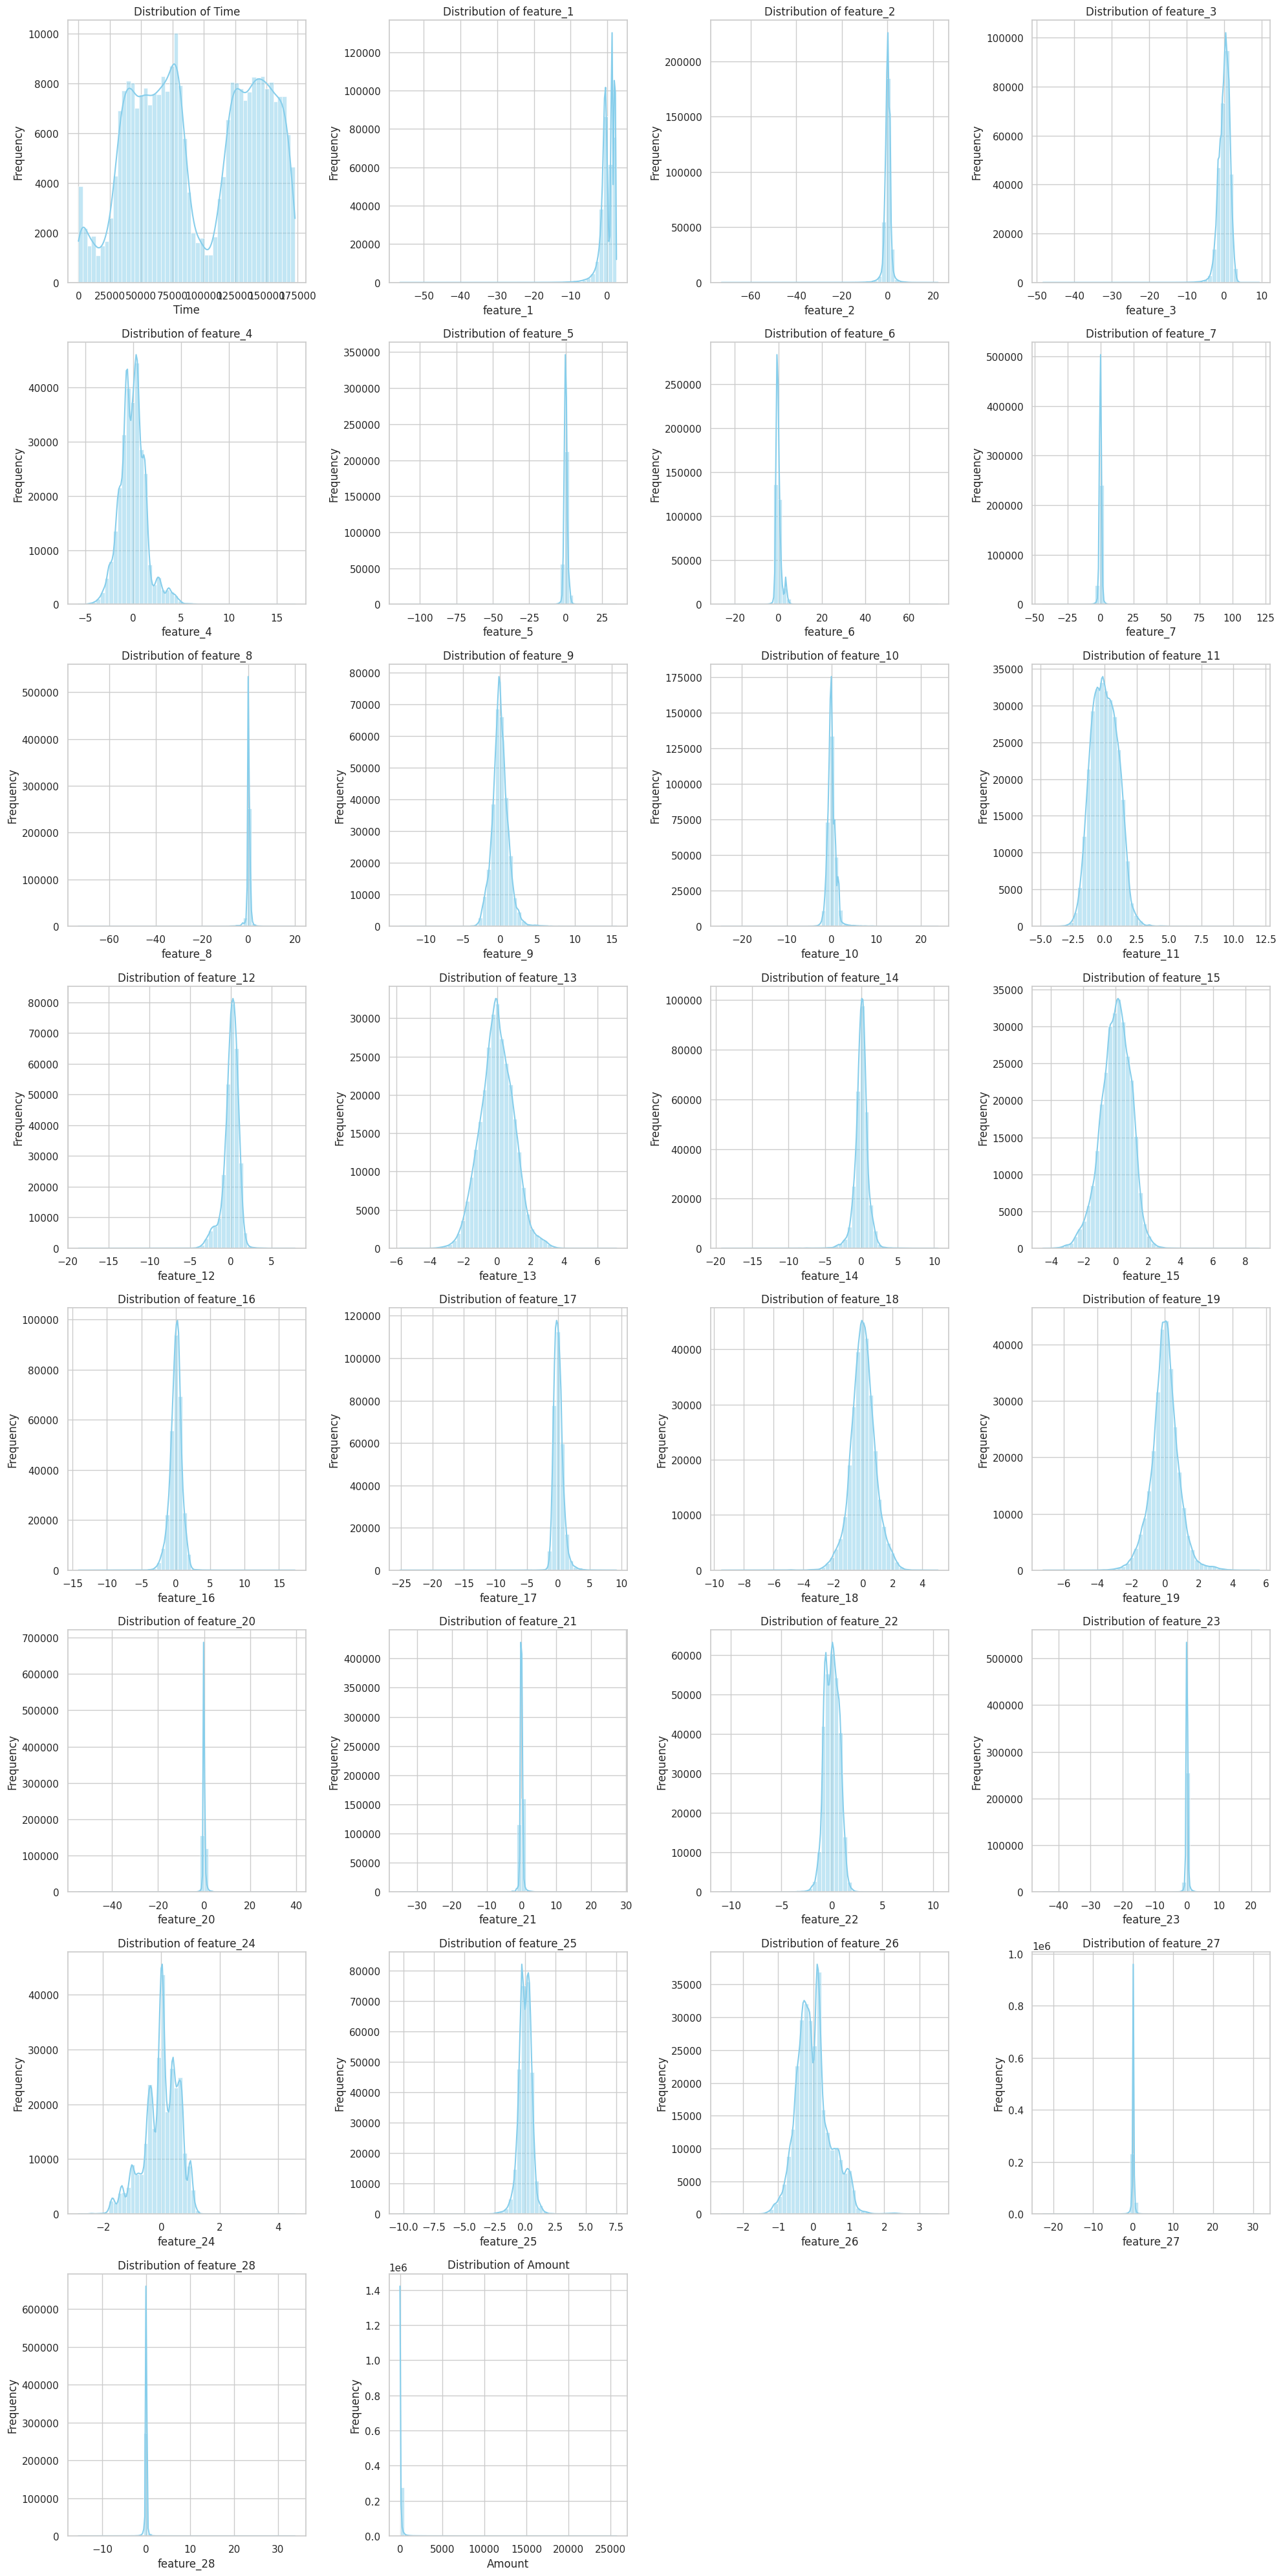

In [12]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Exclude 'Class' as its distribution has been analyzed separately
if 'Class' in numeric_cols:
    numeric_cols.remove('Class')

num_features = len(numeric_cols)
num_rows = (num_features + 3) // 4  # Arrange plots in a 4-column grid

plt.figure(figsize=(20, 5 * num_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
plt.show()

### 2.8.4 Correlation Analysis

Understanding the relationships between features and with the target variable ('Class') is crucial. A correlation matrix and heatmap will help visualize these relationships.

In [13]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display correlations with the 'Class' variable
class_correlations = correlation_matrix['Class'].sort_values(ascending=False)

print("\nCorrelations with the 'Class' variable:")
display(class_correlations)

# Identify features with strong positive or negative correlations with 'Class'
# Define a threshold for strong correlation
correlation_threshold = 0.5

strong_correlations = class_correlations[(class_correlations > correlation_threshold) | (class_correlations < -correlation_threshold)]

if not strong_correlations.empty:
    print(f"\nFeatures with strong correlation (absolute value > {correlation_threshold}) with 'Class':")
    display(strong_correlations)
else:
    print(f"\nNo features with strong correlation (absolute value > {correlation_threshold}) with 'Class' found.")


Correlations with the 'Class' variable:


,Class
Class,1.000000
feature_11,0.149067
feature_4,0.129326
feature_2,0.084624
feature_19,0.033631
feature_8,0.033068
feature_21,0.026357
feature_27,0.021892
feature_20,0.021486
feature_28,0.009682



Features with strong correlation (absolute value > 0.5) with 'Class':


,Class
Class,1.0


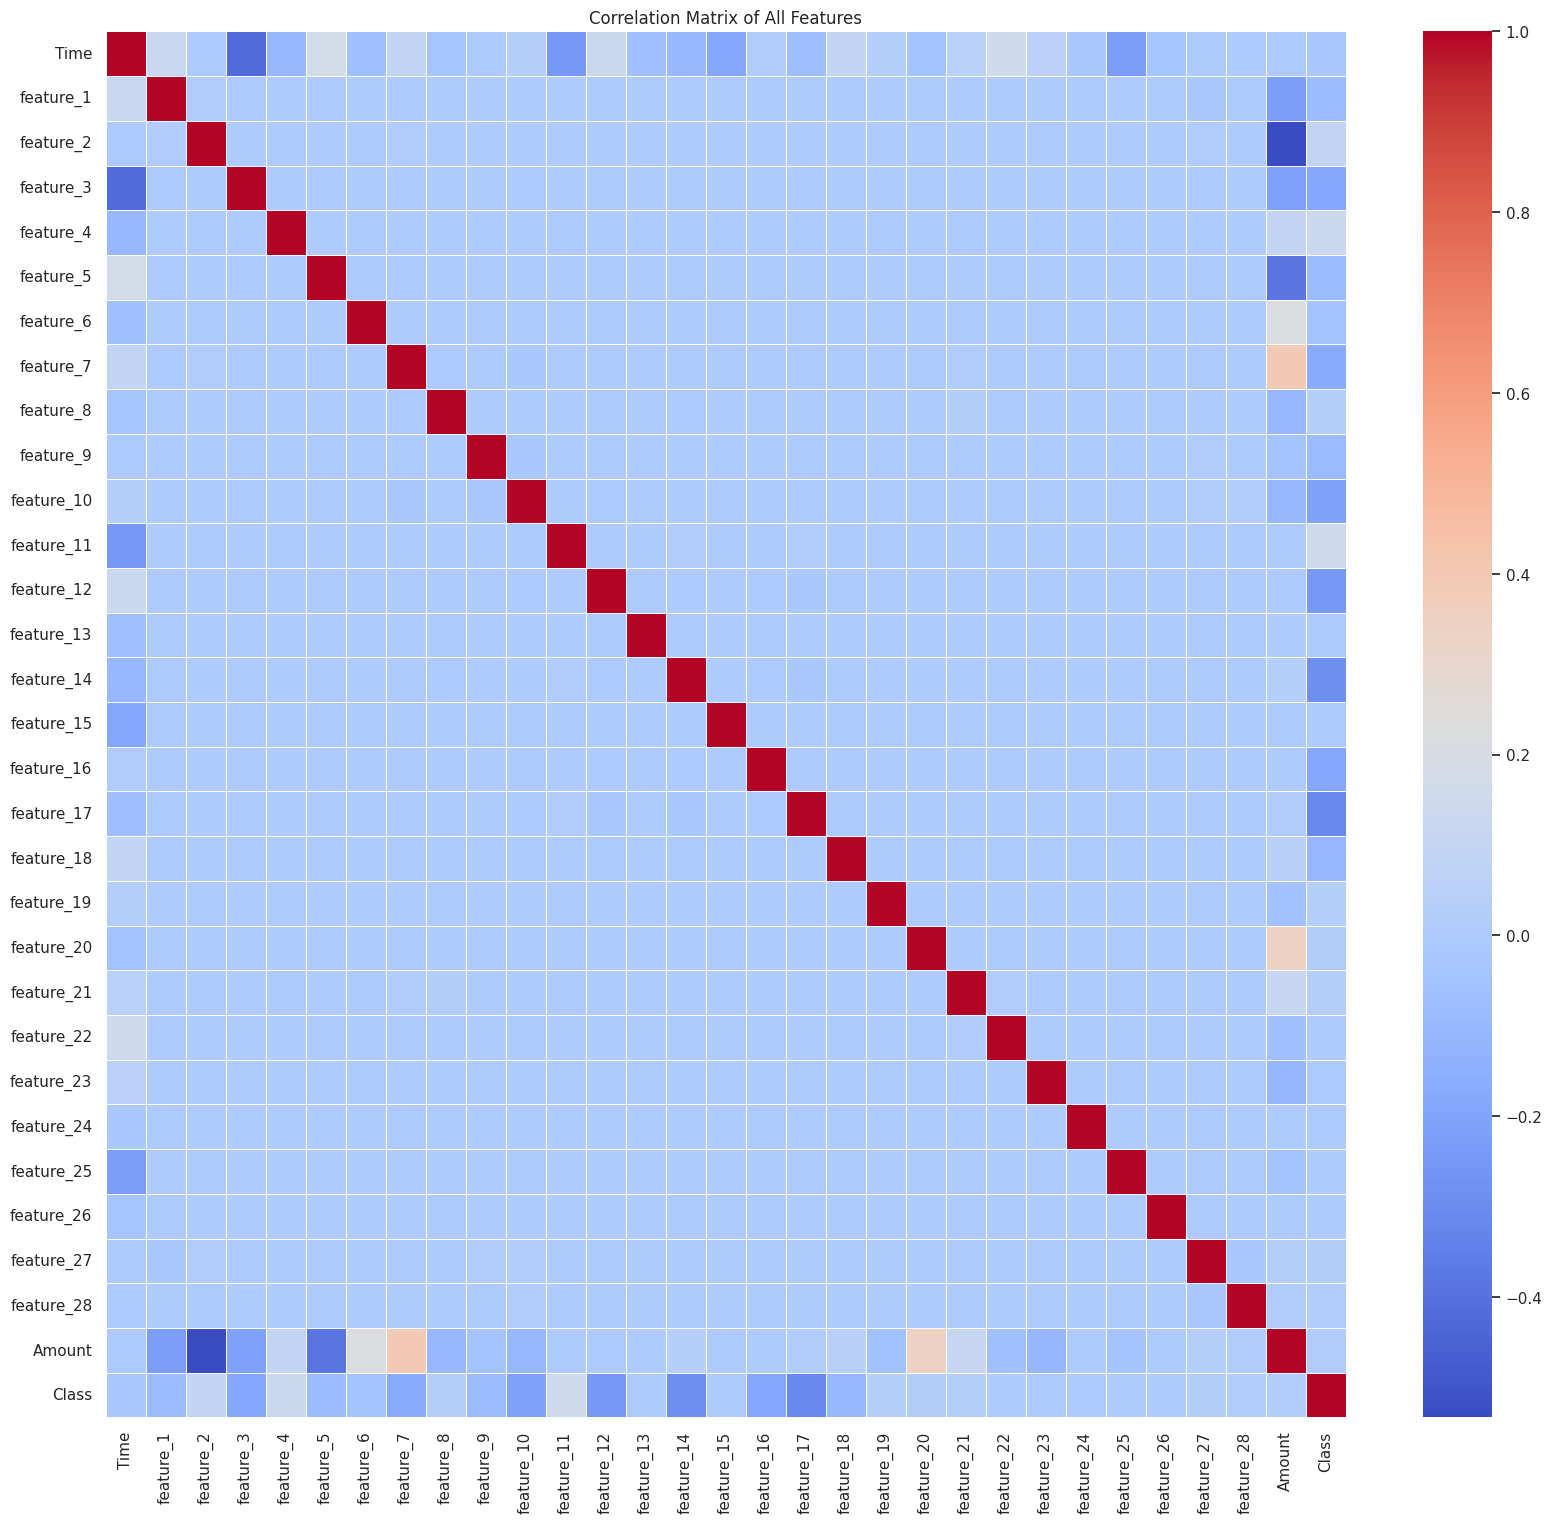

In [14]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

# Part 3: Data Preparation

## 3.1 Data Splitting

We will split the dataset into training and testing sets to evaluate our fraud detection models. A common split is 80% for training and 20% for testing. The 'Class' column is our target variable, and the remaining columns will be used as features.

In [15]:
# Define features (X) and target (y)
X = df.drop(['Class'], axis=1)
y = df['Class']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original dataset shape: {df.shape}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Original dataset shape: (283726, 31)
Training features shape: (226980, 30)
Testing features shape: (56746, 30)
Training target shape: (226980,)
Testing target shape: (56746,)


## 3.2 Stratified K-Fold Cross-Validation

To ensure robust model evaluation, especially with imbalanced datasets, we will use Stratified K-Fold Cross-Validation. This method preserves the percentage of samples for each class in each fold, which is crucial for fraud detection where the minority class (fraudulent transactions) is rare. We will apply a robust scaling method to the Time and Amount features, perform 3-sigma capping for outlier handling, and then apply SMOTE to handle the imbalance issue inside each fold.

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
import numpy as np

# Helper function for 3-sigma outlier capping is now defined globally
def cap_outliers_3sigma(df_in, columns_to_cap):
    df_capped = df_in.copy()
    for col in columns_to_cap:
        if col in df_capped.columns:
            mean = df_capped[col].mean()
            std = df_capped[col].std()
            lower_bound = mean - 3 * std
            upper_bound = mean + 3 * std
            df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
    return df_capped

# Initialize RobustScaler and SMOTE outside the loop
smote = SMOTE(random_state=42)

# Define the number of folds for cross-validation
n_splits = 5 # A common choice for k

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"Initialized Stratified K-Fold with {n_splits} splits.")

print("Demonstrating preprocessing and data distribution within the first fold:")
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold+1}:")

    # Get training and validation data for the current fold
    X_train_fold, X_val_fold = X_train.iloc[train_index].copy(), X_train.iloc[val_index].copy()
    y_train_fold, y_val_fold = y_train.iloc[train_index].copy(), y_train.iloc[val_index].copy()

    # Apply outlier capping to 'Amount' only
    X_train_fold = cap_outliers_3sigma(X_train_fold, ['Amount'])
    X_val_fold = cap_outliers_3sigma(X_val_fold, ['Amount'])
    print("  Outliers capped using 3-sigma method for 'Amount' only within the fold.")

    # Initialize RobustScaler for each fold to avoid data leakage
    scaler = RobustScaler()

    # Apply RobustScaler to 'Time' and 'Amount' columns within the fold
    X_train_fold['Time'] = scaler.fit_transform(X_train_fold[['Time']])
    X_val_fold['Time'] = scaler.transform(X_val_fold[['Time']])

    X_train_fold['Amount'] = scaler.fit_transform(X_train_fold[['Amount']])
    X_val_fold['Amount'] = scaler.transform(X_val_fold[['Amount']])
    print("  RobustScaler applied to 'Time' and 'Amount' for this fold.")

    # Apply SMOTE to the training data of the current fold
    X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)

    print("  SMOTE applied to training data of this fold.")
    print(f"  Original class distribution in training fold:\n{y_train_fold.value_counts(normalize=True)}")
    print(f"  Class distribution after SMOTE (training fold):\n{y_train_fold_smote.value_counts(normalize=True)}")
    print(f"  Class distribution in VALIDATION fold:\n{y_val_fold.value_counts(normalize=True)}")
    if fold == 0: # Only show details for the first fold for brevity
        # Optional: display head of processed data for the first fold
        # print("  X_train_fold_smote head after scaling and SMOTE:")
        # display(X_train_fold_smote.head())
        break

Initialized Stratified K-Fold with 5 splits.
Demonstrating preprocessing and data distribution within the first fold:

Fold 1:
  Outliers capped using 3-sigma method for 'Amount' only within the fold.
  RobustScaler applied to 'Time' and 'Amount' for this fold.
  SMOTE applied to training data of this fold.
  Original class distribution in training fold:
Class
0    0.998331
1    0.001669
Name: proportion, dtype: float64
  Class distribution after SMOTE (training fold):
Class
0    0.5
1    0.5
Name: proportion, dtype: float64
  Class distribution in VALIDATION fold:
Class
0    0.998348
1    0.001652
Name: proportion, dtype: float64


# Part 4: Modelling


## 4.1 Model Training and Evaluation with Cross-Validation

Now we will train several classification models using the preprocessed data within each fold of the Stratified K-Fold Cross-Validation. For each model, we will fit it on the 3-sigma capped, robust-scaled, and SMOTE-resampled training data and evaluate its performance on the validation data for that fold. We will focus on key metrics such as accuracy, precision, recall, F1-score, and ROC AUC, which are particularly important for imbalanced datasets like ours.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, classification_report
import numpy as np # Ensure np is imported for array operations

# Helper function for 3-sigma outlier capping is now defined globally
def cap_outliers_3sigma(df, columns):
    df_capped = df.copy()
    for col in columns:
        mean = df_capped[col].mean()
        std = df_capped[col].std()
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
    return df_capped

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress verbose output
}

# Dictionary to store results for each model and fold
results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'pr_auc': []} for name in models.keys()} # Changed 'roc_auc' to 'pr_auc'

print(f"Starting model training and evaluation across {n_splits} folds...")

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    # Get training and validation data for the current fold
    X_train_fold, X_val_fold = X_train.iloc[train_index].copy(), X_train.iloc[val_index].copy()
    y_train_fold, y_val_fold = y_train.iloc[train_index].copy(), y_train.iloc[val_index].copy()

    # Apply outlier capping to 'Amount' only
    X_train_fold = cap_outliers_3sigma(X_train_fold, ['Amount'])
    X_val_fold = cap_outliers_3sigma(X_val_fold, ['Amount'])
    print("  Outliers capped using 3-sigma method for 'Amount' only within the fold.")

    # Initialize RobustScaler for each fold to avoid data leakage
    scaler = RobustScaler()

    # Apply RobustScaler to 'Time' and 'Amount' columns within the fold
    X_train_fold['Time'] = scaler.fit_transform(X_train_fold[['Time']])
    X_val_fold['Time'] = scaler.transform(X_val_fold[['Time']])

    X_train_fold['Amount'] = scaler.fit_transform(X_train_fold[['Amount']])
    X_val_fold['Amount'] = scaler.transform(X_val_fold[['Amount']])
    print("  RobustScaler applied to 'Time' and 'Amount' for this fold.")

    # Apply SMOTE to the training data of the current fold
    X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)

    print(f"  Fold {fold+1} Preprocessing Complete. Training samples (SMOTE): {len(y_train_fold_smote)}, Validation samples: {len(y_val_fold)}")

    for name, model in models.items():
        print(f"  Training {name}...")
        # Isolation Forest specific logic is now removed
        model.fit(X_train_fold_smote, y_train_fold_smote)
        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)[:, 1] # Probability of the positive class (fraud)

        # Calculate metrics
        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred, zero_division=0)
        rec = recall_score(y_val_fold, y_pred, zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, zero_division=0)
        pr_auc = average_precision_score(y_val_fold, y_proba) # Calculated PR AUC

        # Store results
        results[name]['accuracy'].append(acc)
        results[name]['precision'].append(prec)
        results[name]['recall'].append(rec)
        results[name]['f1_score'].append(f1)
        results[name]['pr_auc'].append(pr_auc) # Stored PR AUC

        print(f"    {name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}, PR AUC: {pr_auc:.4f}") # Updated print statement
        # print(f"\n    Classification Report for {name} (Fold {fold+1}):\n{classification_report(y_val_fold, y_pred, zero_division=0)}")

# Print average results across all folds
print("\n--- Average Metrics Across All Folds ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric_name, values in metrics.items():
        print(f"  Average {metric_name}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

Starting model training and evaluation across 5 folds...

--- Fold 1/5 ---
  Outliers capped using 3-sigma method for 'Amount' only within the fold.
  RobustScaler applied to 'Time' and 'Amount' for this fold.
  Fold 1 Preprocessing Complete. Training samples (SMOTE): 362562, Validation samples: 45396
  Training Logistic Regression...
    Logistic Regression - Accuracy: 0.9741, Precision: 0.0543, Recall: 0.8933, F1-Score: 0.1023, PR AUC: 0.7546
  Training Random Forest...
    Random Forest - Accuracy: 0.9996, Precision: 0.9508, Recall: 0.7733, F1-Score: 0.8529, PR AUC: 0.8435
  Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:08:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    XGBoost - Accuracy: 0.9994, Precision: 0.8571, Recall: 0.8000, F1-Score: 0.8276, PR AUC: 0.8100
  Training LightGBM...
    LightGBM - Accuracy: 0.9991, Precision: 0.7037, Recall: 0.7600, F1-Score: 0.7308, PR AUC: 0.7703

--- Fold 2/5 ---
  Outliers capped using 3-sigma method for 'Amount' only within the fold.
  RobustScaler applied to 'Time' and 'Amount' for this fold.
  Fold 2 Preprocessing Complete. Training samples (SMOTE): 362562, Validation samples: 45396
  Training Logistic Regression...
    Logistic Regression - Accuracy: 0.9713, Precision: 0.0486, Recall: 0.8800, F1-Score: 0.0921, PR AUC: 0.7324
  Training Random Forest...
    Random Forest - Accuracy: 0.9996, Precision: 0.9143, Recall: 0.8533, F1-Score: 0.8828, PR AUC: 0.8682
  Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:18:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    XGBoost - Accuracy: 0.9993, Precision: 0.7442, Recall: 0.8533, F1-Score: 0.7950, PR AUC: 0.8689
  Training LightGBM...
    LightGBM - Accuracy: 0.9989, Precision: 0.6132, Recall: 0.8667, F1-Score: 0.7182, PR AUC: 0.8424

--- Fold 3/5 ---
  Outliers capped using 3-sigma method for 'Amount' only within the fold.
  RobustScaler applied to 'Time' and 'Amount' for this fold.
  Fold 3 Preprocessing Complete. Training samples (SMOTE): 362564, Validation samples: 45396
  Training Logistic Regression...
    Logistic Regression - Accuracy: 0.9791, Precision: 0.0667, Recall: 0.8816, F1-Score: 0.1240, PR AUC: 0.6964
  Training Random Forest...
    Random Forest - Accuracy: 0.9994, Precision: 0.8906, Recall: 0.7500, F1-Score: 0.8143, PR AUC: 0.7867
  Training XGBoost...


...

    XGBoost - Accuracy: 0.9993, Precision: 0.7838, Recall: 0.7632, F1-Score: 0.7733, PR AUC: 0.7879
  Training LightGBM...
    LightGBM - Accuracy: 0.9987, Precision: 0.5960, Recall: 0.7763, F1-Score: 0.6743, PR AUC: 0.7305

--- Fold 4/5 ---
  Outliers capped using 3-sigma method for 'Amount' only within the fold.
  RobustScaler applied to 'Time' and 'Amount' for this fold.
  Fold 4 Preprocessing Complete. Training samples (SMOTE): 362564, Validation samples: 45396
  Training Logistic Regression...
    Logistic Regression - Accuracy: 0.9750, Precision: 0.0585, Recall: 0.9211, F1-Score: 0.1100, PR AUC: 0.7591
  Training Random Forest...
    Random Forest - Accuracy: 0.9995, Precision: 0.8553, Recall: 0.8553, F1-Score: 0.8553, PR AUC: 0.8299
  Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    XGBoost - Accuracy: 0.9994, Precision: 0.8072, Recall: 0.8816, F1-Score: 0.8428, PR AUC: 0.8832
  Training LightGBM...
    LightGBM - Accuracy: 0.9989, Precision: 0.6204, Recall: 0.8816, F1-Score: 0.7283, PR AUC: 0.8437

--- Fold 5/5 ---
  Outliers capped using 3-sigma method for 'Amount' only within the fold.
  RobustScaler applied to 'Time' and 'Amount' for this fold.
  Fold 5 Preprocessing Complete. Training samples (SMOTE): 362564, Validation samples: 45396
  Training Logistic Regression...
    Logistic Regression - Accuracy: 0.9741, Precision: 0.0586, Recall: 0.9605, F1-Score: 0.1104, PR AUC: 0.7573
  Training Random Forest...
    Random Forest - Accuracy: 0.9996, Precision: 0.8919, Recall: 0.8684, F1-Score: 0.8800, PR AUC: 0.8491
  Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:48:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    XGBoost - Accuracy: 0.9993, Precision: 0.7674, Recall: 0.8684, F1-Score: 0.8148, PR AUC: 0.8707
  Training LightGBM...
    LightGBM - Accuracy: 0.9989, Precision: 0.6337, Recall: 0.8421, F1-Score: 0.7232, PR AUC: 0.7779

--- Average Metrics Across All Folds ---

Logistic Regression:
  Average accuracy: 0.9747 (+/- 0.0025)
  Average precision: 0.0573 (+/- 0.0059)
  Average recall: 0.9073 (+/- 0.0304)
  Average f1_score: 0.1077 (+/- 0.0105)
  Average pr_auc: 0.7400 (+/- 0.0238)

Random Forest:
  Average accuracy: 0.9995 (+/- 0.0001)
  Average precision: 0.9006 (+/- 0.0314)
  Average recall: 0.8201 (+/- 0.0485)
  Average f1_score: 0.8570 (+/- 0.0246)
  Average pr_auc: 0.8355 (+/- 0.0273)

XGBoost:
  Average accuracy: 0.9994 (+/- 0.0001)
  Average precision: 0.7920 (+/- 0.0386)
  Average recall: 0.8333 (+/- 0.0447)
  Average f1_score: 0.8107 (+/- 0.0244)
  Average pr_auc: 0.8441 (+/- 0.0379)

LightGBM:
  Average accuracy: 0.9989 (+/- 0.0001)
  Average precision: 0.6334 (+/- 0.0372)
  A

## 4.2 Hyperparameter Tuning for Top Models

Now that we've identified Random Forest and XGBoost as top performers, we'll fine-tune their hyperparameters to further optimize their performance. We will use `RandomizedSearchCV` for efficiency, combining it with our existing preprocessing steps (outlier capping, robust scaling, and SMOTE) within a pipeline.

First, we need to apply the initial preprocessing (capping and scaling) to the full training and test datasets once. Then, `RandomizedSearchCV` will handle the SMOTE application within its cross-validation loops.

In [22]:
from sklearn.preprocessing import RobustScaler

# Re-initialize scaler for full dataset application
scaler = RobustScaler()

# Ensure `cap_outliers_3sigma` is available from previous cells
def cap_outliers_3sigma(df, columns):
    df_capped = df.copy()
    for col in columns:
        mean = df_capped[col].mean()
        std = df_capped[col].std()
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
    return df_capped

# Apply 3-sigma outlier capping to 'Amount' only in X_train
X_train_capped = cap_outliers_3sigma(X_train.copy(), ['Amount'])

print("Outliers capped for 'Amount' in full training dataset.")

# Apply RobustScaler to 'Time' and 'Amount' in the capped datasets
X_train_processed = X_train_capped.copy()

# Correctly fit and transform both 'Time' and 'Amount' columns together
X_train_processed[['Time', 'Amount']] = scaler.fit_transform(X_train_processed[['Time', 'Amount']])

print("RobustScaler applied to 'Time' and 'Amount' for full training dataset.")

display(X_train_processed.head())

Outliers capped for 'Amount' in full training dataset.
RobustScaler applied to 'Time' and 'Amount' for full training dataset.


,Time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,Amount
226238,0.701730,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,0.137472
134253,-0.048166,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.209119
186465,0.496931,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.098808
149493,0.076666,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.066242
18461,-0.649581,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,0.026608


### 4.2.1 Hyperparameter Tuning for Random Forest

We will use `RandomizedSearchCV` with a predefined parameter grid for the Random Forest Classifier. The `SMOTE` step will be integrated into the cross-validation process to ensure it's applied correctly to each training fold. The scoring metric will be `average_precision` (PR AUC).

In [23]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Use imblearn's pipeline for SMOTE integration
from sklearn.preprocessing import StandardScaler # RobustScaler already applied, StandardScaler for general pipeline usage if needed

# Define the parameter grid for Random Forest
param_grid_rf = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_features': ['sqrt', 'log2', None],
    'randomforestclassifier__max_depth': [10, 20, 30, None],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__bootstrap': [True, False]
}

# Create a pipeline with SMOTE and RandomForestClassifier
# The RobustScaler and capping are applied upfront to X_train_processed
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomforestclassifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # n_jobs=-1 for parallel processing
])

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_grid_rf,
    n_iter=5, # Number of parameter settings that are sampled. Reduce for faster run, increase for better results
    cv=skf, # Use the previously defined StratifiedKFold
    scoring='average_precision',
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=2
)

# --- Modification to use a smaller subset of data for faster tuning ---
# Define the fraction of the training data to use for hyperparameter tuning
sampling_fraction = 0.02 # Use 2% of the training data for tuning

# Create a subset of the training data for faster tuning
X_train_subset_rf, _, y_train_subset_rf, _ = train_test_split(
    X_train_processed, y_train, train_size=sampling_fraction, random_state=42, stratify=y_train
)

print(f"Starting RandomizedSearchCV for Random Forest with a {sampling_fraction*100}% subset of the training data...")
print(f"Subset shape: {X_train_subset_rf.shape}")

random_search_rf.fit(X_train_subset_rf, y_train_subset_rf)

print("Random Forest tuning complete!")
print(f"Best parameters for Random Forest: {random_search_rf.best_params_}")
print(f"Best PR AUC score for Random Forest: {random_search_rf.best_score_:.4f}")

Starting RandomizedSearchCV for Random Forest with a 2.0% subset of the training data...
Subset shape: (4539, 30)
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Random Forest tuning complete!
Best parameters for Random Forest: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': 20, 'randomforestclassifier__bootstrap': True}
Best PR AUC score for Random Forest: 0.9002


### 4.2.2 Hyperparameter Tuning for XGBoost

Similarly, we will use `RandomizedSearchCV` to tune the XGBoost Classifier, integrating SMOTE into the cross-validation and using `average_precision` as the scoring metric.

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split # Ensure train_test_split is imported for sampling

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgbclassifier__max_depth': [3, 5, 7, 10],
    'xgbclassifier__subsample': [0.6, 0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0],
    'xgbclassifier__gamma': [0, 0.1, 0.2, 0.5],
    'xgbclassifier__lambda': [0.5, 1, 2],
    'xgbclassifier__alpha': [0, 0.1, 0.2]
}

# Create a pipeline with SMOTE and XGBClassifier
pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgbclassifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)) # n_jobs=-1 for parallel processing
])

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=5, # Number of parameter settings that are sampled. Reduce for faster run, increase for better results
    cv=skf, # Use the previously defined StratifiedKFold
    scoring='average_precision',
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=2
)

# --- Modification to use a smaller subset of data for faster tuning ---
# Use the same sampling fraction as for Random Forest, or adjust as needed
sampling_fraction = 0.02

# Create a subset of the training data for faster tuning
X_train_subset_xgb, _, y_train_subset_xgb, _ = train_test_split(
    X_train_processed, y_train, train_size=sampling_fraction, random_state=42, stratify=y_train
)

print(f"Starting RandomizedSearchCV for XGBoost with a {sampling_fraction*100}% subset of the training data...")
print(f"Subset shape: {X_train_subset_xgb.shape}")

random_search_xgb.fit(X_train_subset_xgb, y_train_subset_xgb)

print("XGBoost tuning complete!")
print(f"Best parameters for XGBoost: {random_search_xgb.best_params_}")
print(f"Best PR AUC score for XGBoost: {random_search_xgb.best_score_:.4f}")

Starting RandomizedSearchCV for XGBoost with a 2.0% subset of the training data...
Subset shape: (4539, 30)
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:51:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost tuning complete!
Best parameters for XGBoost: {'xgbclassifier__subsample': 0.8, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__max_depth': 10, 'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__lambda': 2, 'xgbclassifier__gamma': 0, 'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__alpha': 0.1}
Best PR AUC score for XGBoost: 0.9002


# Part 4: Final Model Training and Evaluation on Test Set

We will now use the best hyperparameters found by `RandomizedSearchCV` to train the Random Forest and XGBoost models on the entire preprocessed training dataset (`X_train_processed`, `y_train`). Subsequently, we will evaluate these final models on the preprocessed test set (`X_test`, `y_test`) to get an unbiased estimate of their performance.

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, classification_report

# --- Prepare the test data (X_test) with the same preprocessing steps as X_train ---

# Note: The `cap_outliers_3sigma` function and `scaler` (RobustScaler) were already defined and fitted in previous steps.
# We will use the fitted scaler to transform the test data.

# Apply 3-sigma outlier capping to 'Amount' only in X_test
X_test_capped = cap_outliers_3sigma(X_test.copy(), ['Amount'])

print("Outliers capped for 'Amount' in test dataset.")

# Apply RobustScaler to 'Time' and 'Amount' in the capped test dataset
X_test_processed = X_test_capped.copy()

# Correctly transform both 'Time' and 'Amount' columns together
X_test_processed[['Time', 'Amount']] = scaler.transform(X_test_processed[['Time', 'Amount']])

print("RobustScaler applied to 'Time' and 'Amount' for test dataset.")

display(X_test_processed.head())

Outliers capped for 'Amount' in test dataset.
RobustScaler applied to 'Time' and 'Amount' for test dataset.


,Time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,Amount
86568,-0.276378,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,-0.146619
251557,0.829134,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,-0.279102
20232,-0.633616,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,0.958980
68952,-0.371382,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,2.853659
191852,0.524103,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,-0.286447


In [26]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Helper function to strip prefixes from best_params_
def strip_prefix_params(params, prefix):
    return {key.replace(prefix, ''): value for key, value in params.items()}

print("--- Training Final Random Forest Model ---")

# Get best parameters for Random Forest
best_params_rf = random_search_rf.best_params_
stripped_params_rf = strip_prefix_params(best_params_rf, 'randomforestclassifier__')

# Create final Random Forest pipeline with best parameters
final_rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomforestclassifier', RandomForestClassifier(random_state=42, n_jobs=-1, **stripped_params_rf))
])

# Train the final model on the full preprocessed training data
print("Training Random Forest on full X_train_processed...")
final_rf_pipeline.fit(X_train_processed, y_train)
print("Random Forest training complete.")

# Evaluate on the preprocessed test set
y_pred_rf = final_rf_pipeline.predict(X_test_processed)
y_proba_rf = final_rf_pipeline.predict_proba(X_test_processed)[:, 1]

# Calculate and print metrics
print("\n--- Random Forest Evaluation on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"PR AUC: {average_precision_score(y_test, y_proba_rf):.4f}")

print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


--- Training Final Random Forest Model ---
Training Random Forest on full X_train_processed...
Random Forest training complete.

--- Random Forest Evaluation on Test Set ---
Accuracy: 0.9994
Precision: 0.8409
Recall: 0.7789
F1-Score: 0.8087
PR AUC: 0.8203

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.78      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [27]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Helper function `strip_prefix_params` is already defined in the previous cell.

print("--- Training Final XGBoost Model ---")

# Get best parameters for XGBoost
best_params_xgb = random_search_xgb.best_params_
stripped_params_xgb = strip_prefix_params(best_params_xgb, 'xgbclassifier__')

# Create final XGBoost pipeline with best parameters
final_xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgbclassifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, **stripped_params_xgb))
])

# Train the final model on the full preprocessed training data
print("Training XGBoost on full X_train_processed...")
final_xgb_pipeline.fit(X_train_processed, y_train)
print("XGBoost training complete.")

# Evaluate on the preprocessed test set
y_pred_xgb = final_xgb_pipeline.predict(X_test_processed)
y_proba_xgb = final_xgb_pipeline.predict_proba(X_test_processed)[:, 1]

# Calculate and print metrics
print("\n--- XGBoost Evaluation on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"PR AUC: {average_precision_score(y_test, y_proba_xgb):.4f}")

print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))


--- Training Final XGBoost Model ---
Training XGBoost on full X_train_processed...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training complete.

--- XGBoost Evaluation on Test Set ---
Accuracy: 0.9993
Precision: 0.8021
Recall: 0.8105
F1-Score: 0.8063
PR AUC: 0.8162

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.80      0.81      0.81        95

    accuracy                           1.00     56746
   macro avg       0.90      0.91      0.90     56746
weighted avg       1.00      1.00      1.00     56746



### Summary of Final Model Performance

The evaluation results on the held-out test set provide an estimate of how the fine-tuned Random Forest and XGBoost models are expected to perform on unseen data. These metrics are crucial for understanding the trade-offs between different models in the context of fraud detection.